# Tutorial 5: CRC multi-capture analysis

In [1]:
import remap
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Load ST reference and scRNA-seq data
##### Source data can be downloaded from the link: https://drive.google.com/drive/folders/11UHBbEkVJ5i5drp-7WV9nAwdUuaIr-WD
##### For multi-capture training, we combined all ST captures into one anndata object, with a column in the adata.obs to indicate the source labels. In this data, ```Rdata.obs['source']``` indicates the capture ID.
##### The batch effect corrected expressions are stored in `Rdata.obsm['corrected']` and `Qdata.obsm['corrected']`. If no external batch correction is applied, setting `harmony = TRUE` in the `remap.Fit_cord_multi` function will run Harmony internally to remove batch effects.

In [2]:
Rdata = ad.read_h5ad("data/crc_multi/st_data.h5ad")
Qdata = ad.read_h5ad("data/crc_multi/sc_data.h5ad")
print(Rdata)
print(Qdata)

AnnData object with n_obs × n_vars = 60497 × 422
    obs: 'x_cord', 'y_cord', 'n_genes', 'n_counts', 'Cluster', 'source'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'covet', 'spatial'
AnnData object with n_obs × n_vars = 68010 × 11855
    obs: 'x_cord', 'y_cord', 'Cluster', 'Cluster_10', 'n_genes', 'n_counts'
    var: 'feature_types', 'genome', 'gene', 'n_cells'
    obsm: 'covet'


## Initialize neighboring gene-gene covariance estimation.
##### For multi-capture training, please add the parameter `batch_key = 'source'` to indicate the capture source label column.
##### After training, initialized neighboring gene-gene covariance for ST and scRNA-seq will be saved to `path_name` in `npy` format, named as `st_covariance.npy` and `sc_covariance.npy`.

In [3]:
data_name = "crc_multi"
path_name =  f"remap_output/{data_name}"

Rdata, Qdata = remap.covet_init(st_data = Rdata, sc_data = Qdata, num_covet_genes=100, k_nearest=100, num_HVG=1000, batch_key = 'source',
                 save_path = path_name, covet_batch_size = None, log_input = 0.0, lib_size = False)

Loading precomputed neighboring gene-gene covariance


## Fit location prediction model.
##### We use `Fit_cord_multi` to train the prediction model with multiple ST captures. `equal_size` is a parameter to indicate whether each ST capture has equal size. If not, please change `equal_size=False`, and the locations of each ST capture will be rescaled by their location range.
##### For multi-capture training, please add the parameter `batch_key = 'source'` to indicate the capture source label column.
##### If the primary goal is to identify spatial neighbors and construct CN clusters/spatial niches, predicting the full pairwise distance matrix is often unnecessary. For each cell, only the pairwise distances of candidate neighbors will be predicted. In this case, please set `full_pairwise = False`.
##### The predicted pairwise distance will be saved to `path_name` in `npz` format.
##### If no external batch effect correction methods are applied, setting `harmony = True` is recommended to remove gene expression batch effect using Harmony

In [ ]:
dist_pred = remap.Fit_cord_multi(Rdata = Rdata, location_data = Rdata.obs[['x_cord', 'y_cord']], Qdata = Qdata, path_name = path_name, 
                                 full_pairwise = False, neighbor_fraction=0.1,
                                 source_key = "source", equal_size = True, harmony = False)
print(dist_pred.shape)

In [4]:
from scipy.sparse import load_npz

data_name = "crc_multi"
path_name =  f"remap_output/{data_name}"
dist_pred = load_npz(f"{path_name}/remap_rel_dist.npz")

## Cellular Neighborhood (CN) clustering and spatial proximity quantification 
##### Performed CN clustering based on predicted pairwise distance matrix. Here, cells were plotted under true locations and colored by ground-truth or predicted CN clusters.

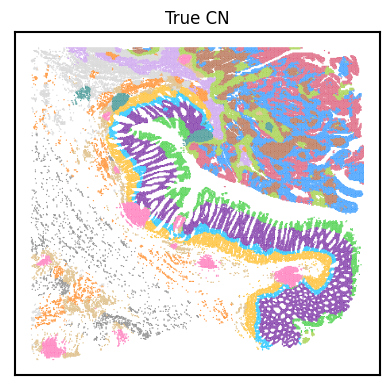

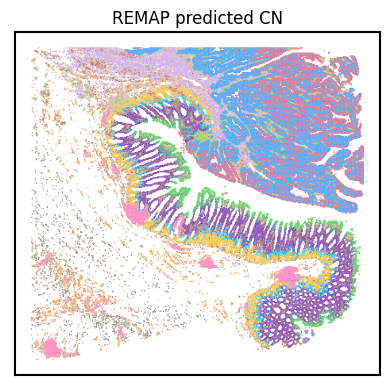

In [5]:
knn = 100
n_clust = 15

Qdata.obsm['spatial'] = np.array(Qdata.obs[['x_cord', 'y_cord']])
cn_true = remap.cn_cluster(Qdata.obs, Qdata.obs[['x_cord', 'y_cord']], ct_key = "Cluster", n_clust=n_clust, knn=knn)
cn_remap = remap.cn_cluster(Qdata.obs, dist_pred, ct_key = "Cluster", n_clust=n_clust, knn=knn)
Qdata.obs['CN_true'] = cn_true
Qdata.obs['CN_remap'] = cn_remap


## CN numbering is arbitrary in each run, so relabel CN_remap into CN_true's
## numbering once (Hungarian matching on the contingency table). Purely cosmetic:
## from here on the same CN id means the same neighborhood in both label sets, and
## every figure below can use one `colors`.
cluster_corr = remap.match_clusters(Qdata.obs, key_ref = 'CN_true', key_new = 'CN_remap')
Qdata.obs['CN_remap'] = Qdata.obs['CN_remap'].map(cluster_corr)


colors = {'1': '#DB4C6C', '2': '#00BFFF', '3': '#D1D1D1', '4': '#6D1A9C', '5': '#9ACD32', 
          '6': '#DAB370', '7': '#32CD32', '8': '#1E90FF', '9': '#FF69B4', '10': '#FF7F0E', '11': '#FEB915', 
          '12': '#C798EE', '13': '#268785', '14': '#787878', '15': '#AF5F3C'}

remap.scatter_plot(Qdata, colors, spatial_key = "spatial", cluster_key = 'CN_true', s = 0.75, title = "True CN")
remap.scatter_plot(Qdata, colors, spatial_key = "spatial", cluster_key = 'CN_remap', s = 0.75, title = "REMAP predicted CN")

##### NMI between ground-truth and predicted CN cluster labels

In [6]:
from sklearn.metrics import normalized_mutual_info_score
normalized_mutual_info_score(cn_true, cn_remap)

0.4916938576316199